# POS Hypothesis Explorer

This notebook analyzes all hypothesis groups produced by `train_pos.py` runs stored under `resources/results/`.

It is organized around the experiment groups:

- **Group A** — baseline family comparison
- **Group B** — data regime
- **Group C** — context length / max sequence length
- **Group D** — optimization sensitivity
- **Group E** — robustness across split seeds and run seeds

For each group, the notebook shows:

1. a summary table,
2. tailored visualizations,
3. what to look for,
4. a short interpretation aid.

## Important comparability note

Comparisons are most meaningful **within a hypothesis group**, where the intended controls are fixed.

When configs vary things like:
- sentence count,
- max sequence length,
- train/test split seed,

then comparing raw scores **across groups** is less meaningful than comparing them **inside the group that was designed for that hypothesis**.


## How to use

1. Make sure your experiment JSON outputs exist under `resources/results/`.
2. Adjust `PROJECT_ROOT` below if needed.
3. Run all cells from top to bottom.
4. Use `SELECTION_METRIC` near the top to choose how “best” is defined.

Recommended metrics:
- `f1` for overall model quality
- `token_accuracy` for straightforward token-level comparison
- `best_val_accuracy` to inspect validation performance


In [11]:
from pathlib import Path

# Adjust if needed
PROJECT_ROOT = Path("/home/dan-gavriluta/Coding/ml-project")
RESULTS_ROOT = PROJECT_ROOT / "resources" / "results"
MODELS_ROOT = PROJECT_ROOT / "resources" / "models"

SELECTION_METRIC = "f1"  # options: f1, token_accuracy, precision, recall, best_val_accuracy

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print("Exists:", RESULTS_ROOT.exists())


PROJECT_ROOT: /home/dan-gavriluta/Coding/ml-project
RESULTS_ROOT: /home/dan-gavriluta/Coding/ml-project/resources/results
Exists: True


In [12]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
sns.set_theme(style="whitegrid")

def load_all_result_files(results_root: Path):
    return sorted(results_root.rglob("training_results.json"))

def load_all_runs(results_root: Path):
    files = load_all_result_files(results_root)
    runs = []
    for fp in files:
        with fp.open("r", encoding="utf-8") as f:
            payload = json.load(f)
        if isinstance(payload, dict):
            payload = [payload]
        for run in payload:
            run["_results_file"] = str(fp)
            run["_results_folder"] = str(fp.parent)
            runs.append(run)
    return files, runs

def flatten_run(run):
    row = {
        "name": run.get("name"),
        "model_type": run.get("model_type"),
        "best_val_accuracy": run.get("best_val_accuracy"),
        "best_val_loss": run.get("best_val_loss"),
        "train_time_sec": run.get("train_time_sec"),
        "num_params": run.get("num_params"),
        "epochs_ran": run.get("epochs_ran"),
        "model_path": run.get("model_path"),
        "model_saved": run.get("model_saved"),
        "_results_file": run.get("_results_file"),
        "_results_folder": run.get("_results_folder"),
    }

    tm = run.get("test_metrics", {})
    for k, v in tm.items():
        row[k] = v

    cfg = run.get("config", {})
    for k, v in cfg.items():
        row[f"cfg_{k}"] = v

    dm = run.get("dataset_meta", {})
    row["group"] = cfg.get("group")
    row["hypothesis"] = cfg.get("hypothesis")
    row["sentences"] = dm.get("sentences", cfg.get("sentences"))
    row["maxlen"] = dm.get("maxlen", cfg.get("maxlen"))
    row["split_seed"] = dm.get("split_seed", cfg.get("split_seed"))
    row["run_seed"] = dm.get("seed", cfg.get("seed"))
    row["vocab_size"] = dm.get("vocab_size", cfg.get("vocab_size"))
    row["num_tags"] = dm.get("num_tags", cfg.get("num_tags"))

    return row

def runs_to_df(runs):
    if not runs:
        return pd.DataFrame()
    df = pd.DataFrame([flatten_run(r) for r in runs])

    numeric_cols = [
        "best_val_accuracy", "best_val_loss", "train_time_sec", "num_params", "epochs_ran",
        "token_accuracy", "precision", "recall", "f1",
        "sentences", "maxlen", "split_seed", "run_seed", "vocab_size", "num_tags",
        "cfg_lr", "cfg_dropout", "cfg_batch_size", "cfg_embed_dim", "cfg_ff_dim",
        "cfg_num_layers", "cfg_num_heads", "cfg_lstm_units", "cfg_lstm_layers",
        "cfg_lr_warmup_steps",
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def get_group(df, group_name):
    return df[df["group"] == group_name].copy()

def show_top(df, metric="f1", n=10):
    cols = [
        "name", "group", "model_type", metric,
        "token_accuracy", "best_val_accuracy", "train_time_sec",
        "num_params", "sentences", "maxlen", "split_seed", "run_seed"
    ]
    cols = [c for c in cols if c in df.columns]
    return df.sort_values(metric, ascending=False)[cols].head(n).reset_index(drop=True)

def plot_bar(df_group, metric="f1", title=None, hue="model_type", figsize=(12, 5)):
    if df_group.empty:
        print("No rows for this plot.")
        return
    order = df_group.sort_values(metric, ascending=False)["name"]
    plt.figure(figsize=figsize)
    sns.barplot(data=df_group, x="name", y=metric, hue=hue, order=order)
    plt.xticks(rotation=35, ha="right")
    plt.title(title or f"{metric} by run")
    plt.tight_layout()
    plt.show()

def plot_line(df_group, x, y="f1", hue="model_type", marker="o", title=None, figsize=(10, 5)):
    if df_group.empty:
        print("No rows for this plot.")
        return
    plt.figure(figsize=figsize)
    sns.lineplot(data=df_group.sort_values([hue, x]), x=x, y=y, hue=hue, marker=marker)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

def plot_histories(runs, group_name, metric="val_accuracy", figsize=(10, 5)):
    plt.figure(figsize=figsize)
    used = False
    for run in runs:
        cfg = run.get("config", {})
        if cfg.get("group") != group_name:
            continue
        hist = run.get("history", {})
        vals = hist.get(metric, [])
        if vals:
            used = True
            plt.plot(range(1, len(vals) + 1), vals, label=run.get("name"))
    if not used:
        print("No history found for this group/metric.")
        return
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"{group_name}: {metric}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def annotate_scatter(df_group, x="train_time_sec", y="f1", figsize=(8, 5), title=None):
    if df_group.empty:
        print("No rows for this plot.")
        return
    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_group, x=x, y=y, hue="model_type", s=80)
    for _, row in df_group.iterrows():
        plt.annotate(row["name"], (row[x], row[y]), fontsize=8)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

def grouped_summary(df_group, by, metric="f1"):
    if df_group.empty:
        return pd.DataFrame()
    return (
        df_group.groupby(by, dropna=False)[metric]
        .agg(["count", "mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

def heatmap_split_seed_vs_run_seed(df_group, metric="f1", model_type=None, figsize=(6, 5)):
    temp = df_group.copy()
    if model_type is not None:
        temp = temp[temp["model_type"] == model_type]
    if temp.empty:
        print("No rows for this heatmap.")
        return
    pivot = temp.pivot_table(index="split_seed", columns="run_seed", values=metric, aggfunc="mean")
    plt.figure(figsize=figsize)
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis")
    title = f"{metric} heatmap"
    if model_type:
        title += f" — {model_type}"
    plt.title(title)
    plt.tight_layout()
    plt.show()

def practical_score(df, metric="f1", time_penalty=0.001):
    out = df.copy()
    out["practical_score"] = out[metric] - time_penalty * out["train_time_sec"].fillna(0)
    return out

files, runs = load_all_runs(RESULTS_ROOT)
df = runs_to_df(runs)

print(f"Found {len(files)} result file(s)")
print(f"Loaded {len(runs)} run(s)")

Found 7 result file(s)
Loaded 74 run(s)


In [13]:
if df.empty:
    print("No results found. Run experiments first.")
else:
    display(Markdown("### Discovered result files"))
    display(pd.DataFrame({"results_file": [str(f) for f in files]}))

    display(Markdown("### Overall top runs"))
    display(show_top(df, metric=SELECTION_METRIC, n=15))

    display(Markdown("### Run counts by group"))
    group_counts = df.groupby(["group", "model_type"]).size().reset_index(name="runs")
    display(group_counts.sort_values(["group", "model_type"]).reset_index(drop=True))


### Discovered result files

,results_file
0,/home/dan-gavriluta/Coding/ml-project/resources/results/group_A_baseline_family_comparison/training_results.json
1,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json
2,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json
3,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json
4,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness/training_results.json
5,/home/dan-gavriluta/Coding/ml-project/resources/results/group_F_lr_warmup/training_results.json
6,/home/dan-gavriluta/Coding/ml-project/resources/results/group_G_architecture_depth/training_results.json


### Overall top runs

,name,group,model_type,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params,sentences,maxlen,split_seed,run_seed
0,B_lstm_stronger_smax,B_data_regime,lstm,0.925927,0.926844,0.926444,106.397920,4764435,12543,30,42,42
1,B_lstm_stronger_s5000,B_data_regime,lstm,0.907573,0.907544,0.919581,40.801338,2843667,5000,30,42,42
2,B_transformer_medium_smax,B_data_regime,transformer,0.896975,0.897979,0.906029,42.921002,9112851,12543,30,42,42
3,C_lstm_stronger_len100,C_context_length_regime,lstm,0.895106,0.897549,0.894381,74.365063,2052883,2000,100,42,42
4,C_lstm_stronger_len50,C_context_length_regime,lstm,0.895036,0.897557,0.893349,38.662162,2052883,2000,50,42,42
5,E_lstm_stronger_split7_run123,E_robustness,lstm,0.894989,0.897542,0.889848,25.892051,2052883,2000,30,7,123
6,D_lstm_dropout_02,D_optimization_sensitivity,lstm,0.892042,0.894437,0.892159,26.133188,2052883,2000,30,42,42
7,D_lstm_dropout_03,D_optimization_sensitivity,lstm,0.891984,0.894437,0.893235,29.052266,2052883,2000,30,42,42
8,D_lstm_dropout_01,D_optimization_sensitivity,lstm,0.891421,0.893868,0.892518,26.031880,2052883,2000,30,42,42
9,E_lstm_stronger_split123_run123,E_robustness,lstm,0.890715,0.892752,0.888793,24.435571,2052883,2000,30,123,123


### Run counts by group

,group,model_type,runs
0,A_baseline_family_comparison,lstm,2
1,A_baseline_family_comparison,transformer,2
2,B_data_regime,lstm,5
3,B_data_regime,transformer,5
4,C_context_length_regime,lstm,4
5,C_context_length_regime,transformer,4
6,D_optimization_sensitivity,lstm,11
7,D_optimization_sensitivity,transformer,11
8,E_robustness,lstm,9
9,E_robustness,transformer,9


## Overall interpretation guide

Use these rules while reading the plots:

- **Higher `f1` / `token_accuracy` is better**
- **Lower `best_val_loss` is better**
- **Lower `train_time_sec` is better**
- If one family wins by only a tiny margin but is much slower, check the practical tradeoff
- For groups that vary data size or max length, compare trends, not just one isolated bar
- For robustness, prefer **mean performance + low variance** over one lucky best run


In [14]:
leaderboard_cols = [
    "name", "group", "model_type",
    "token_accuracy", "f1", "precision", "recall",
    "best_val_accuracy", "best_val_loss",
    "train_time_sec", "epochs_ran",
]

config_cols = [
    "name", "model_type",
    "num_params",
    "cfg_embed_dim", "cfg_num_heads", "cfg_ff_dim", "cfg_num_layers",
    "cfg_lstm_units", "cfg_lstm_layers", "cfg_dropout", "cfg_lr",
    "cfg_lr_warmup_steps", "cfg_batch_size",
]

meta_cols = [
    "name", "model_type",
    "sentences", "maxlen", "split_seed", "run_seed",
    "vocab_size", "num_tags",
    "predict_batch_size_used", "predict_device",
]

# Group A — Baseline family comparison

**Hypothesis**  
A medium Transformer should outperform a reasonable BiLSTM on the default setup.

**Controlled factors**
- same sentence count
- same max length
- same split seed
- same run seed

**What to look for**
- Does `A_transformer_medium` beat `A_lstm_stronger` on `f1` and `token_accuracy`?
- Does `A_transformer_small` already beat `A_lstm_baseline`, or only the medium Transformer does?
- Is the Transformer gain large enough to matter, or tiny relative to training cost?
- Do validation curves suggest overfitting for either family?


### Leadership

,name,group,model_type,token_accuracy,f1,precision,recall,best_val_accuracy,best_val_loss,train_time_sec,epochs_ran
0,A_lstm_stronger,A_baseline_family_comparison,lstm,0.890738,0.887984,0.889578,0.890738,0.887493,0.383989,25.682021,16
1,A_lstm_baseline,A_baseline_family_comparison,lstm,0.890596,0.887874,0.891803,0.890596,0.888032,0.384210,21.248130,13
2,A_transformer_small,A_baseline_family_comparison,transformer,0.832266,0.830228,0.834316,0.832266,0.834739,0.552305,13.456119,7
3,A_transformer_medium,A_baseline_family_comparison,transformer,0.825722,0.823940,0.827490,0.825722,0.837431,0.557828,24.421414,8


### Config

,name,model_type,num_params,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_lstm_units,cfg_lstm_layers,cfg_dropout,cfg_lr,cfg_lr_warmup_steps,cfg_batch_size
0,A_transformer_medium,transformer,6401299,256,8.0,512.0,2.0,NaN,NaN,0.1,0.0010,NaN,128
1,A_lstm_stronger,lstm,2052883,256,NaN,NaN,NaN,128.0,NaN,NaN,0.0005,NaN,32
2,A_transformer_small,transformer,1130515,128,4.0,128.0,1.0,NaN,NaN,0.1,0.0010,NaN,64
3,A_lstm_baseline,lstm,928147,128,NaN,NaN,NaN,64.0,NaN,NaN,0.0010,NaN,32


### Meta

,name,model_type,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,predict_batch_size_used,predict_device
0,A_transformer_small,transformer,2000,30,42,42,6460,19,32,gpu
1,A_transformer_medium,transformer,2000,30,42,42,6460,19,32,gpu
2,A_lstm_baseline,lstm,2000,30,42,42,6460,19,32,gpu
3,A_lstm_stronger,lstm,2000,30,42,42,6460,19,32,gpu


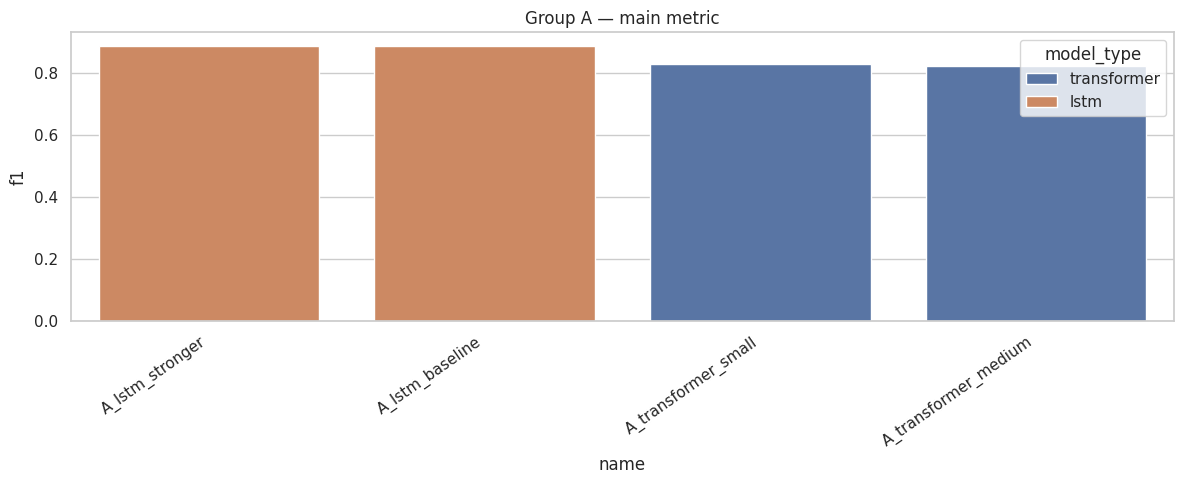

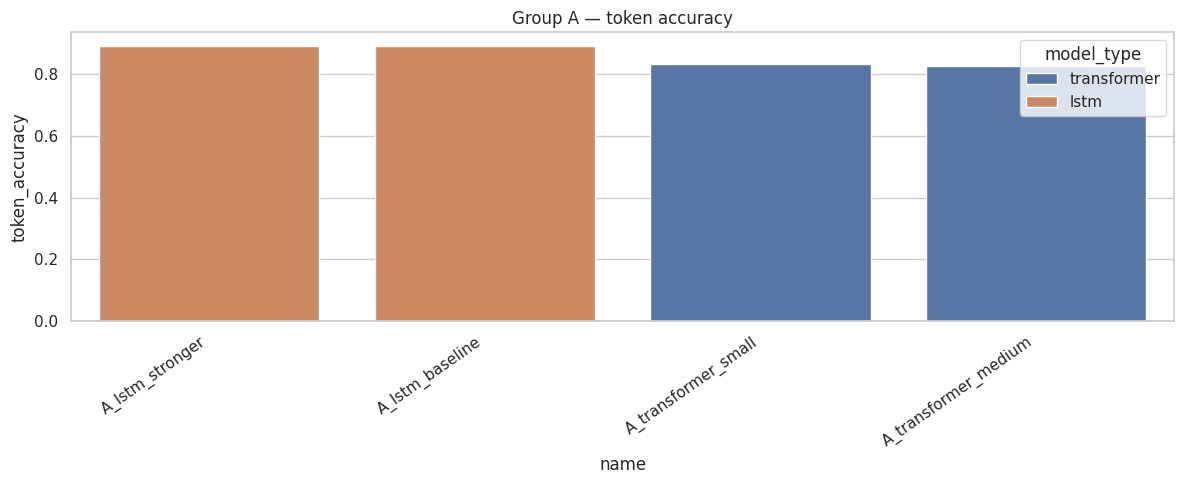

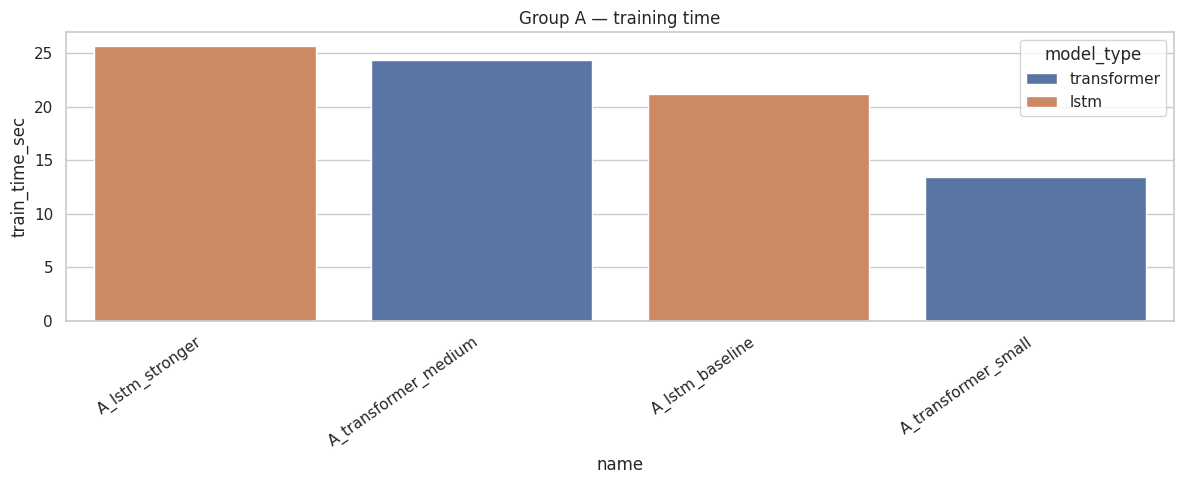

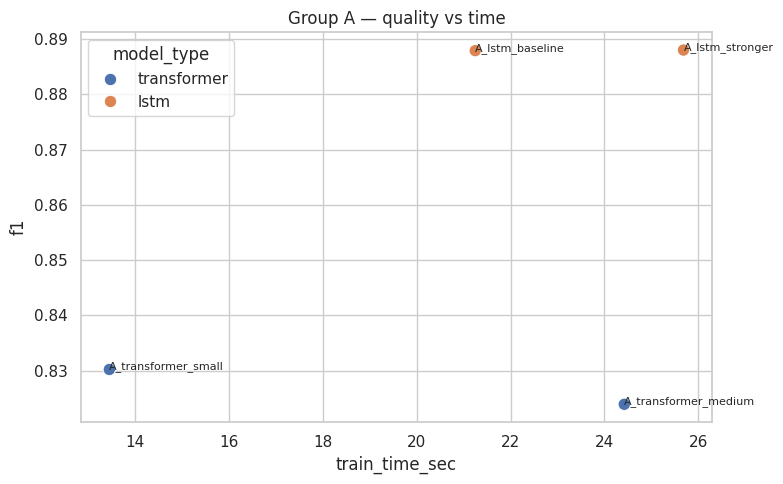

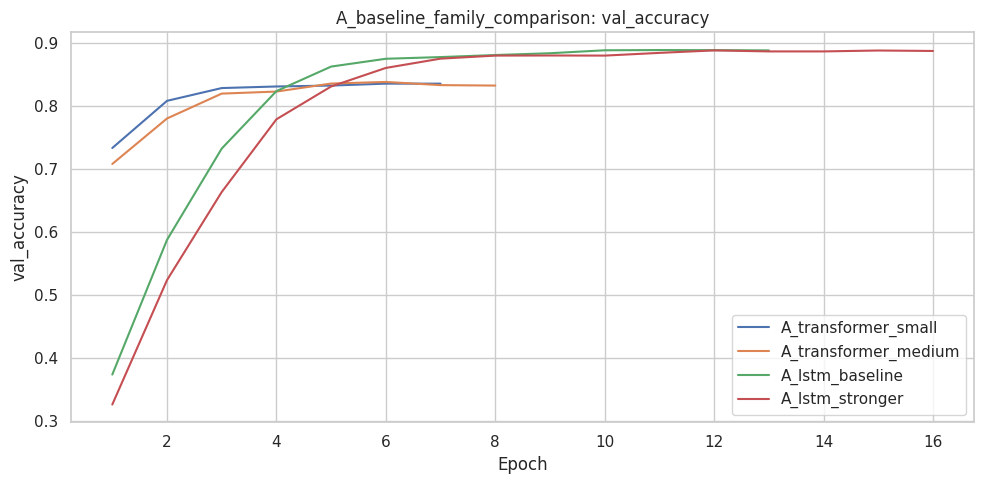

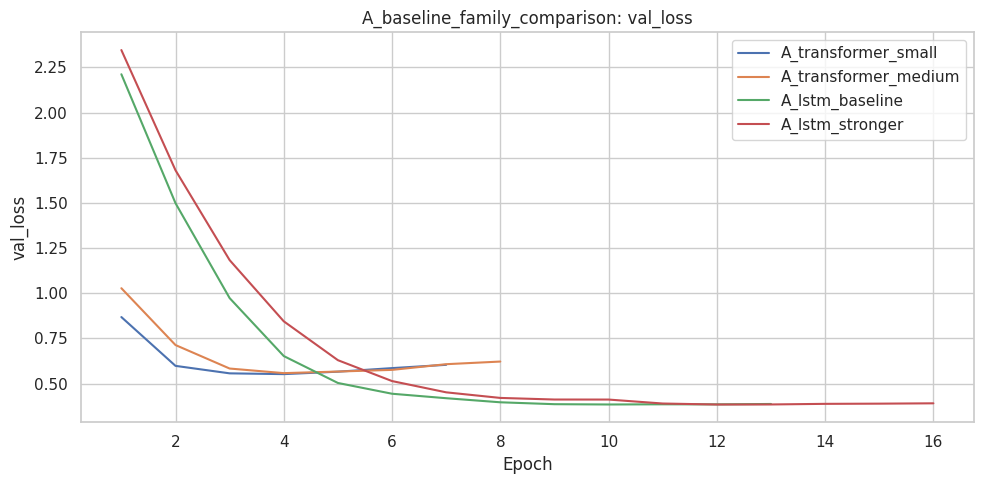

In [15]:
group_a = get_group(df, "A_baseline_family_comparison")

display(Markdown("### Leadership"))
display(
    group_a[leaderboard_cols]
    .sort_values(SELECTION_METRIC, ascending=False)
    .reset_index(drop=True)
)

display(Markdown("### Config"))
display(
    group_a[config_cols]
    .sort_values("num_params", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("### Meta"))
display(
    group_a[meta_cols]
    .reset_index(drop=True)
)

plot_bar(group_a, metric=SELECTION_METRIC, title="Group A — main metric")
plot_bar(group_a, metric="token_accuracy", title="Group A — token accuracy")
plot_bar(group_a, metric="train_time_sec", title="Group A — training time")

annotate_scatter(group_a, x="train_time_sec", y=SELECTION_METRIC, title="Group A — quality vs time")

plot_histories(runs, "A_baseline_family_comparison", "val_accuracy")
plot_histories(runs, "A_baseline_family_comparison", "val_loss")


# Group B — Data regime

**Hypothesis**
- LSTM is more competitive on small data
- Transformer scales better as data increases

**Controlled factors**
- same max length
- same split seed
- same run seed

**What to look for**
- At `sentences = 500` or `1000`, does the gap shrink or flip toward LSTM?
- As sentence count increases, does Transformer improve more steeply?
- Does one family plateau earlier?
- How much extra training time do you pay for the gains?


,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,group,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
0,B_lstm_stronger_s500,lstm,0.836162,0.592779,11.488735,1132307,20,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_lstm_stronger_s500.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.847672,0.847788,0.847672,0.844835,32,gpu,B_lstm_stronger_s500,B_data_regime,H2_lstm_more_competitive_low_data,lstm,500,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,2864,19,B_data_regime,H2_lstm_more_competitive_low_data,500,30,42,42,2864,19,128.0,NaN,NaN
1,B_transformer_medium_s500,transformer,0.787206,0.750407,21.877261,5480723,10,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_transformer_medium_s500.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.795040,0.806493,0.795040,0.792682,32,gpu,B_transformer_medium_s500,B_data_regime,H2_lstm_more_competitive_low_data,transformer,500,30,42,42,256,8.0,512.0,2.0,0.1,0.0010,20,64,True,4,0.2,2864,19,B_data_regime,H2_lstm_more_competitive_low_data,500,30,42,42,2864,19,NaN,NaN,NaN
2,B_lstm_stronger_s1000,lstm,0.876923,0.428178,16.356650,1547027,20,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_lstm_stronger_s1000.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.867582,0.864728,0.867582,0.865414,32,gpu,B_lstm_stronger_s1000,B_data_regime,H2_lstm_more_competitive_low_data,lstm,1000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,4484,19,B_data_regime,H2_lstm_more_competitive_low_data,1000,30,42,42,4484,19,128.0,NaN,NaN
3,B_transformer_medium_s1000,transformer,0.816667,0.640470,29.123208,5895443,9,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_transformer_medium_s1000.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.809795,0.813537,0.809795,0.808173,32,gpu,B_transformer_medium_s1000,B_data_regime,H2_lstm_more_competitive_low_data,transformer,1000,30,42,42,256,8.0,512.0,2.0,0.1,0.0010,20,96,True,4,0.2,4484,19,B_data_regime,H2_lstm_more_competitive_low_data,1000,30,42,42,4484,19,NaN,NaN,NaN
4,B_lstm_stronger_s2000,lstm,0.887493,0.383989,24.711309,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_lstm_stronger_s2000.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.890738,0.889578,0.890738,0.887984,32,gpu,B_lstm_stronger_s2000,B_data_regime,H4_transformer_scales_better_with_more_data,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,B_data_regime,H4_transformer_scales_better_with_more_data,2000,30,42,42,6460,19,128.0,NaN,NaN
5,B_transformer_medium_s2000,transformer,0.837251,0.557916,21.624900,6401299,8,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_transformer_medium_s2000.keras,False,/home/dan-gavriluta/Coding/ml

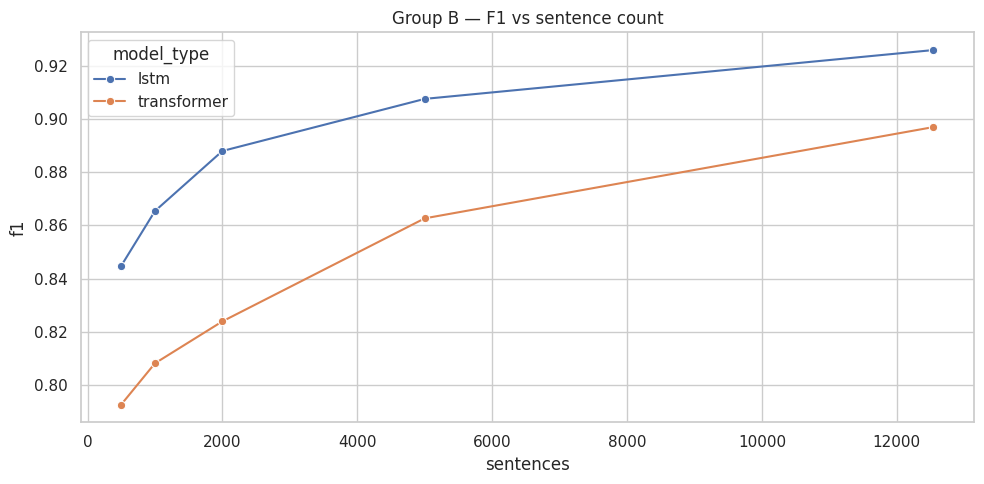

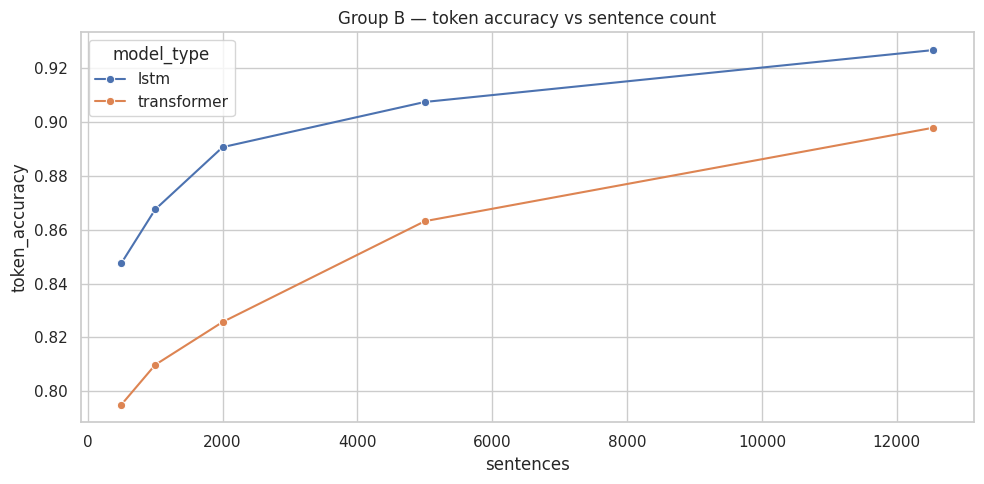

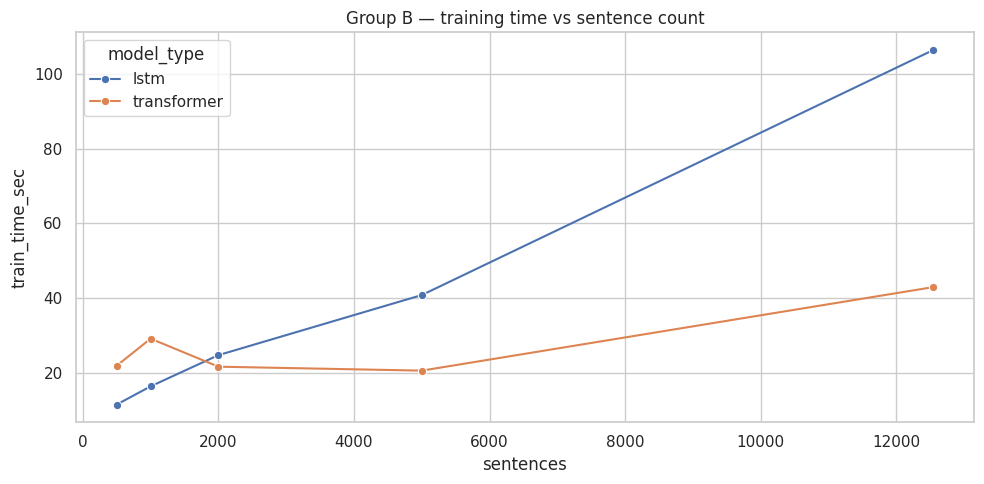

### Group B summary by sentence count

,sentences,model_type,count,mean,std,min,max
0,12543,lstm,1,0.925927,NaN,0.925927,0.925927
1,5000,lstm,1,0.907573,NaN,0.907573,0.907573
2,12543,transformer,1,0.896975,NaN,0.896975,0.896975
3,2000,lstm,1,0.887984,NaN,0.887984,0.887984
4,1000,lstm,1,0.865414,NaN,0.865414,0.865414
5,5000,transformer,1,0.862666,NaN,0.862666,0.862666
6,500,lstm,1,0.844835,NaN,0.844835,0.844835
7,2000,transformer,1,0.823940,NaN,0.823940,0.823940
8,1000,transformer,1,0.808173,NaN,0.808173,0.808173
9,500,transformer,1,0.792682,NaN,0.792682,0.792682


In [16]:
group_b = get_group(df, "B_data_regime")
display(group_b.sort_values(["sentences", "model_type"]).reset_index(drop=True))

plot_line(group_b, x="sentences", y="f1", title="Group B — F1 vs sentence count")
plot_line(group_b, x="sentences", y="token_accuracy", title="Group B — token accuracy vs sentence count")
plot_line(group_b, x="sentences", y="train_time_sec", title="Group B — training time vs sentence count")

display(Markdown("### Group B summary by sentence count"))
display(grouped_summary(group_b, by=["sentences", "model_type"], metric="f1"))


# Group C — Context length / max sequence length

**Hypothesis**  
Transformer should gain more from longer available context than LSTM.

**Controlled factors**
- same sentence count
- same split seed
- same run seed

**What to look for**
- At short max lengths (20, 30), is LSTM relatively close?
- At longer max lengths (50, 100), does Transformer pull ahead?
- Does performance keep improving with max length, or plateau?
- Are longer contexts worth the added training cost?


,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,group,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
0,C_lstm_stronger_len20,lstm,0.874892,0.426894,18.535231,2052883,15,/home/dan-gavriluta/Coding/ml-project/resources/models/group_C_context_length_regime/C_lstm_stronger_len20.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime,0.875888,0.872002,0.875888,0.871697,32,gpu,C_lstm_stronger_len20,C_context_length_regime,H3_transformer_gains_more_from_longer_context,lstm,2000,20,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,C_context_length_regime,H3_transformer_gains_more_from_longer_context,2000,20,42,42,6460,19,128.0,NaN,NaN
1,C_transformer_medium_len20,transformer,0.870938,0.449203,20.143385,6398739,8,/home/dan-gavriluta/Coding/ml-project/resources/models/group_C_context_length_regime/C_transformer_medium_len20.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime,0.815566,0.819061,0.815566,0.813895,32,gpu,C_transformer_medium_len20,C_context_length_regime,H3_transformer_gains_more_from_longer_context,transformer,2000,20,42,42,256,8.0,512.0,2.0,0.10,0.0010,20,128,True,4,0.2,6460,19,C_context_length_regime,H3_transformer_gains_more_from_longer_context,2000,20,42,42,6460,19,NaN,NaN,NaN
2,C_lstm_stronger_len30,lstm,0.887493,0.383989,24.537914,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_C_context_length_regime/C_lstm_stronger_len30.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime,0.890738,0.889578,0.890738,0.887984,32,gpu,C_lstm_stronger_len30,C_context_length_regime,H3_transformer_gains_more_from_longer_context,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,C_context_length_regime,H3_transformer_gains_more_from_longer_context,2000,30,42,42,6460,19,128.0,NaN,NaN
3,C_transformer_medium_len30,transformer,0.903854,0.322827,21.958316,6401299,10,/home/dan-gavriluta/Coding/ml-project/resources/models/group_C_context_length_regime/C_transformer_medium_len30.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime,0.834827,0.836789,0.834827,0.832659,32,gpu,C_transformer_medium_len30,C_context_length_regime,H3_transformer_gains_more_from_longer_context,transformer,2000,30,42,42,256,8.0,512.0,2.0,0.10,0.0010,20,128,True,4,0.2,6460,19,C_context_length_regime,H3_transformer_gains_more_from_longer_context,2000,30,42,42,6460,19,NaN,NaN,NaN
4,C_lstm_stronger_len50,lstm,0.893349,0.371070,38.662162,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_C_context_length_regime/C_lstm_stronger_len50.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime,0.897557,0.896262,0.897557,0.895036,32,gpu,C_lstm_stronger_len50,C_context_length_regime,H3_transformer_gains_more_from_longer_context,lstm,2000,50,42,42,256,NaN,NaN,NaN,

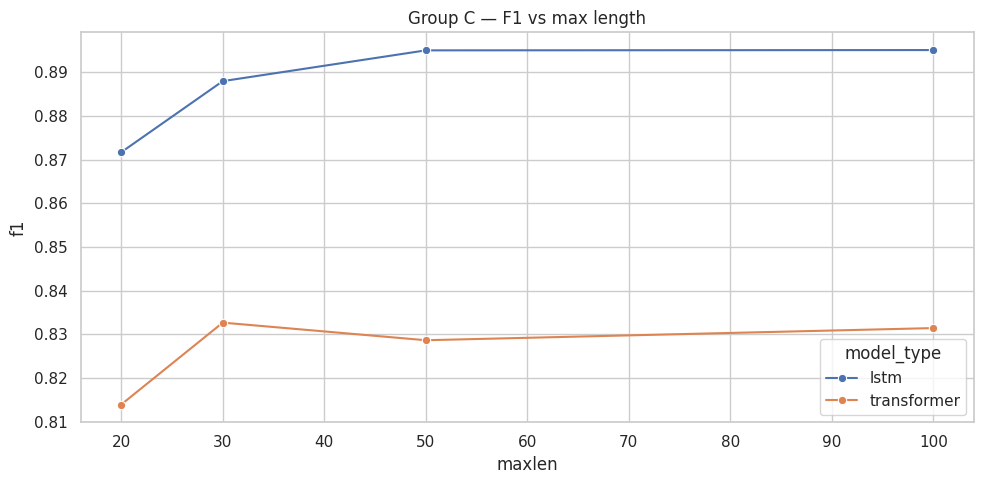

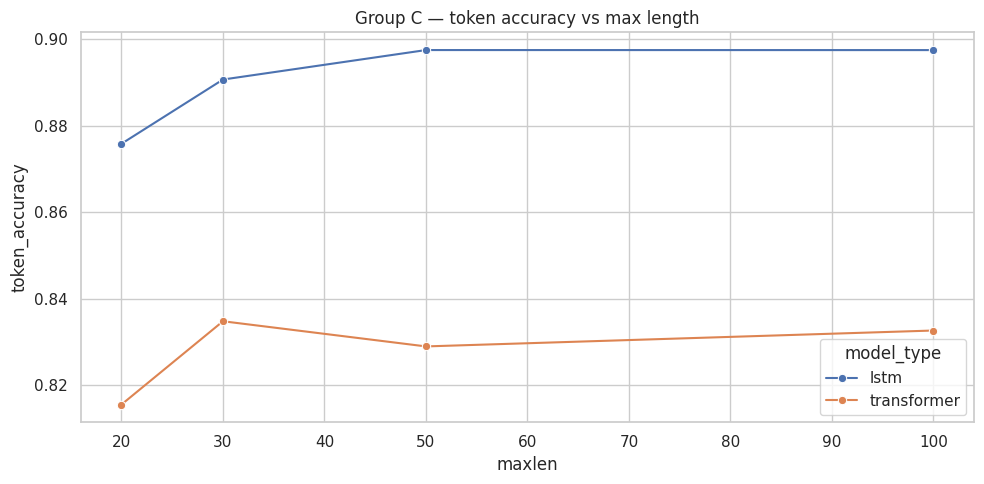

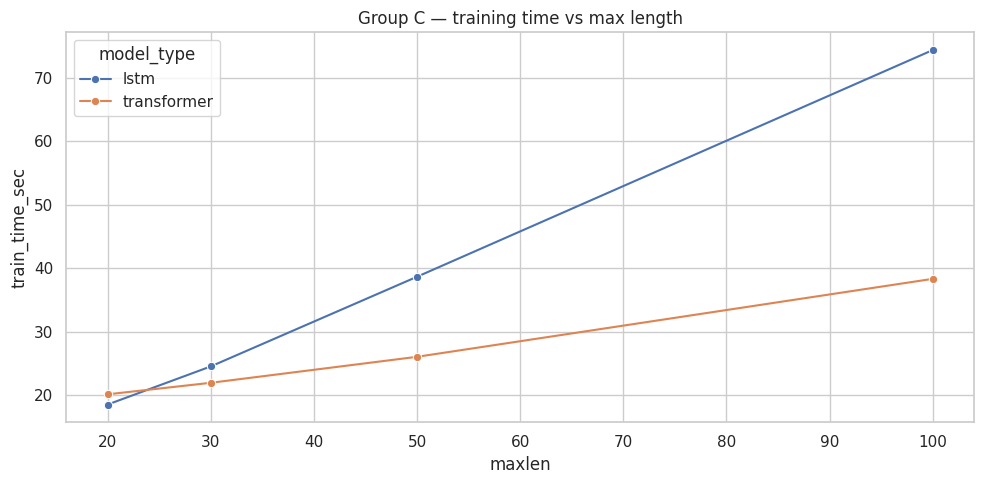

### Group C summary by max length

,maxlen,model_type,count,mean,std,min,max
0,100,lstm,1,0.895106,NaN,0.895106,0.895106
1,50,lstm,1,0.895036,NaN,0.895036,0.895036
2,30,lstm,1,0.887984,NaN,0.887984,0.887984
3,20,lstm,1,0.871697,NaN,0.871697,0.871697
4,30,transformer,1,0.832659,NaN,0.832659,0.832659
5,100,transformer,1,0.831409,NaN,0.831409,0.831409
6,50,transformer,1,0.828626,NaN,0.828626,0.828626
7,20,transformer,1,0.813895,NaN,0.813895,0.813895


In [17]:
group_c = get_group(df, "C_context_length_regime")
display(group_c.sort_values(["maxlen", "model_type"]).reset_index(drop=True))

plot_line(group_c, x="maxlen", y="f1", title="Group C — F1 vs max length")
plot_line(group_c, x="maxlen", y="token_accuracy", title="Group C — token accuracy vs max length")
plot_line(group_c, x="maxlen", y="train_time_sec", title="Group C — training time vs max length")

display(Markdown("### Group C summary by max length"))
display(grouped_summary(group_c, by=["maxlen", "model_type"], metric="f1"))


# Group D — Optimization sensitivity

**Hypotheses**
- Transformer is more sensitive to learning rate
- Transformer is more sensitive to dropout
- Batch size affects Transformer more strongly than LSTM

**Controlled factors**
- same sentence count
- same max length
- same split seed
- same run seed

**What to look for**
- **Learning rate**: does performance swing more for Transformer than LSTM?
- **Dropout**: is there a clear sweet spot for Transformer? Do very low or very high values hurt?
- **Batch size**: does Transformer benefit more from larger batches than LSTM?
- Which family is easier to tune?


,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,group,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
0,D_lstm_batch_128,lstm,0.877983,0.432619,9.990076,2052883,20,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_batch_128.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.879784,0.874497,0.879784,0.875968,32,gpu,D_lstm_batch_128,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,128,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2000,30,42,42,6460,19,128.0,NaN,NaN
1,D_lstm_batch_16,lstm,0.891082,0.383017,37.573199,2052883,12,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_batch_16.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.889316,0.887187,0.889316,0.886824,32,gpu,D_lstm_batch_16,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,16,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2000,30,42,42,6460,19,128.0,NaN,NaN
2,D_lstm_batch_32,lstm,0.887493,0.383989,24.455274,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_batch_32.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.890738,0.889578,0.890738,0.887984,32,gpu,D_lstm_batch_32,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2000,30,42,42,6460,19,128.0,NaN,NaN
3,D_lstm_batch_64,lstm,0.886058,0.385026,16.879781,2052883,20,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_batch_64.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.891165,0.889428,0.891165,0.888729,32,gpu,D_lstm_batch_64,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,64,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2000,30,42,42,6460,19,128.0,NaN,NaN
4,D_lstm_dropout_0,lstm,0.887493,0.383989,24.750594,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_dropout_0.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.890738,0.889578,0.890738,0.887984,32,gpu,D_lstm_dropout_0,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,lstm,2000,30,42,42,256,NaN,NaN,NaN,0.0,0.0005,20,32,True,4,0.2,6460,19,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,2000,30,42,42,6460,19,128.0,Na

### Group D — learning rate sweep

,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,group,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
0,D_lstm_lr_3e4,lstm,0.887673,0.387639,35.657384,2052883,24,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_lr_3e4.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.889458,0.888021,0.889458,0.886681,32,gpu,D_lstm_lr_3e4,D_optimization_sensitivity,H7_transformer_more_sensitive_to_learning_rate,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0003,24,32,True,5,0.2,6460,19,D_optimization_sensitivity,H7_transformer_more_sensitive_to_learning_rate,2000,30,42,42,6460,19,128.0,NaN,NaN
1,D_lstm_lr_5e4,lstm,0.887493,0.383989,24.122361,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_lr_5e4.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.890738,0.889578,0.890738,0.887984,32,gpu,D_lstm_lr_5e4,D_optimization_sensitivity,H7_transformer_more_sensitive_to_learning_rate,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,D_optimization_sensitivity,H7_transformer_more_sensitive_to_learning_rate,2000,30,42,42,6460,19,128.0,NaN,NaN
2,D_lstm_lr_1e3,lstm,0.888570,0.393088,23.013660,2052883,13,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_lr_1e3.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.890881,0.890944,0.890881,0.888976,32,gpu,D_lstm_lr_1e3,D_optimization_sensitivity,H7_transformer_more_sensitive_to_learning_rate,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0010,18,32,True,4,0.2,6460,19,D_optimization_sensitivity,H7_transformer_more_sensitive_to_learning_rate,2000,30,42,42,6460,19,128.0,NaN,NaN
3,D_transformer_lr_3e4,transformer,0.900521,0.341070,12.344682,6401299,13,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_transformer_lr_3e4.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.826433,0.826119,0.826433,0.824220,32,gpu,D_transformer_lr_3e4,D_optimization_sensitivity,H7_transformer_more_sensitive_to_learning_rate,transformer,2000,30,42,42,256,8.0,512.0,2.0,0.1,0.0003,24,128,True,5,0.2,6460,19,D_optimization_sensitivity,H7_transformer_more_sensitive_to_learning_rate,2000,30,42,42,6460,19,NaN,NaN,NaN
4,D_transformer_lr_5e4,transformer,0.901042,0.330625,14.419573,6401299,10,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_transformer_lr_5e4.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.829848,0.830453,0.829848,0.827840,32,gpu,D_transformer_lr_5e4,D_optimization_sensitivity,H7_transformer_more_sensitive_to_learning_rate,transformer,2000,30,42,42,256,8.0,512.0,2.0,0.1,0.0005,22,128,True,4,0.

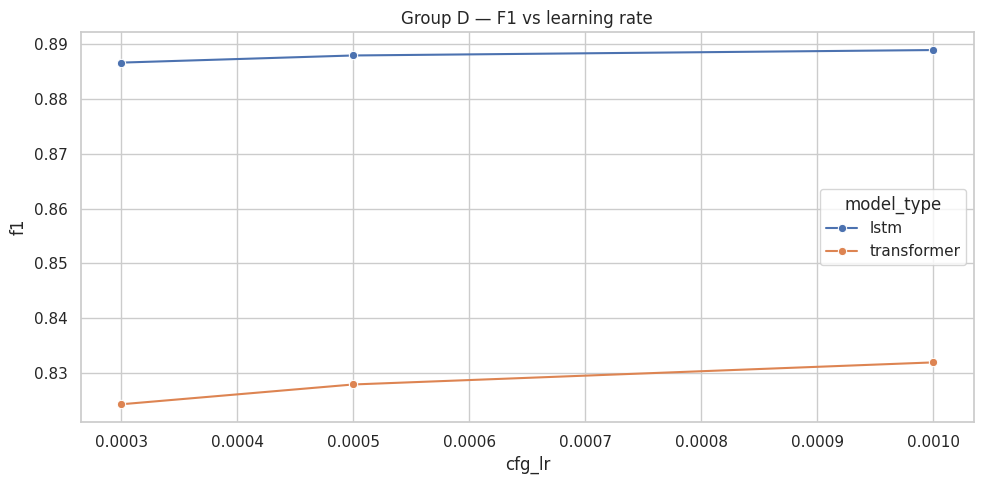

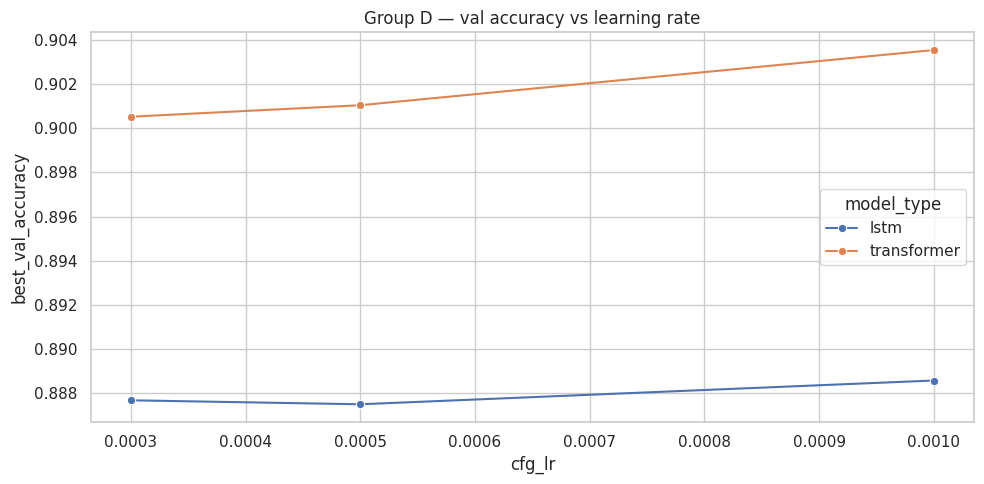

### Group D — dropout sweep

,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,group,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
0,D_lstm_dropout_0,lstm,0.887493,0.383989,24.750594,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_dropout_0.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.890738,0.889578,0.890738,0.887984,32,gpu,D_lstm_dropout_0,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,lstm,2000,30,42,42,256,NaN,NaN,NaN,0.0,0.0005,20,32,True,4,0.2,6460,19,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,2000,30,42,42,6460,19,128.0,NaN,NaN
1,D_lstm_dropout_01,lstm,0.892518,0.374813,26.031880,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_dropout_01.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.893868,0.893391,0.893868,0.891421,32,gpu,D_lstm_dropout_01,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,lstm,2000,30,42,42,256,NaN,NaN,NaN,0.1,0.0005,20,32,True,4,0.2,6460,19,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,2000,30,42,42,6460,19,128.0,NaN,NaN
2,D_lstm_dropout_02,lstm,0.892159,0.374044,26.133188,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_dropout_02.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.894437,0.893797,0.894437,0.892042,32,gpu,D_lstm_dropout_02,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,lstm,2000,30,42,42,256,NaN,NaN,NaN,0.2,0.0005,22,32,True,4,0.2,6460,19,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,2000,30,42,42,6460,19,128.0,NaN,NaN
3,D_lstm_dropout_03,lstm,0.893235,0.373972,29.052266,2052883,19,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_dropout_03.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.894437,0.893683,0.894437,0.891984,32,gpu,D_lstm_dropout_03,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,lstm,2000,30,42,42,256,NaN,NaN,NaN,0.3,0.0005,24,32,True,5,0.2,6460,19,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,2000,30,42,42,6460,19,128.0,NaN,NaN
4,D_transformer_dropout_0,transformer,0.902813,0.329958,14.873077,6401299,12,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_transformer_dropout_0.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.825864,0.828082,0.825864,0.822595,32,gpu,D_transformer_dropout_0,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,transformer,2000,30,42,42,256,8.0,512.0,2.0,0.0,0.0005,22,128,True,4,0.2,6460,19,D_optimization_sensitivity

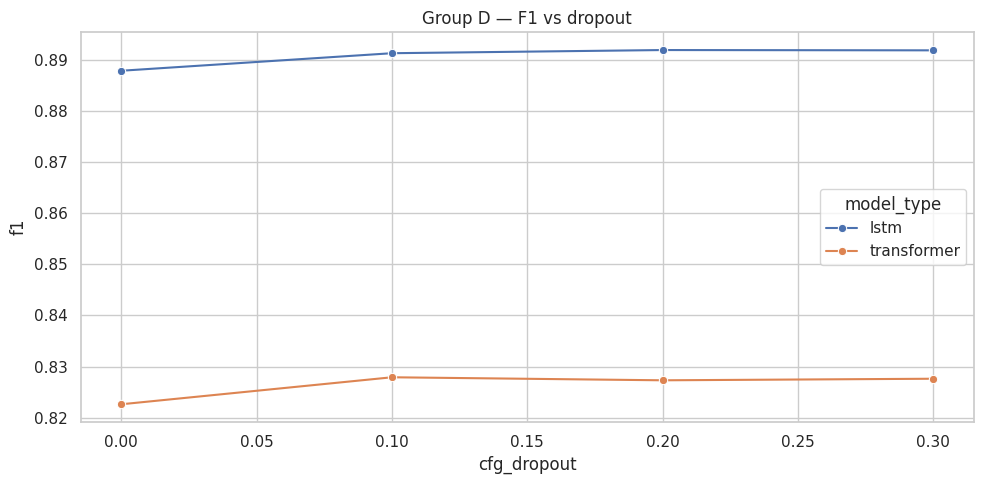

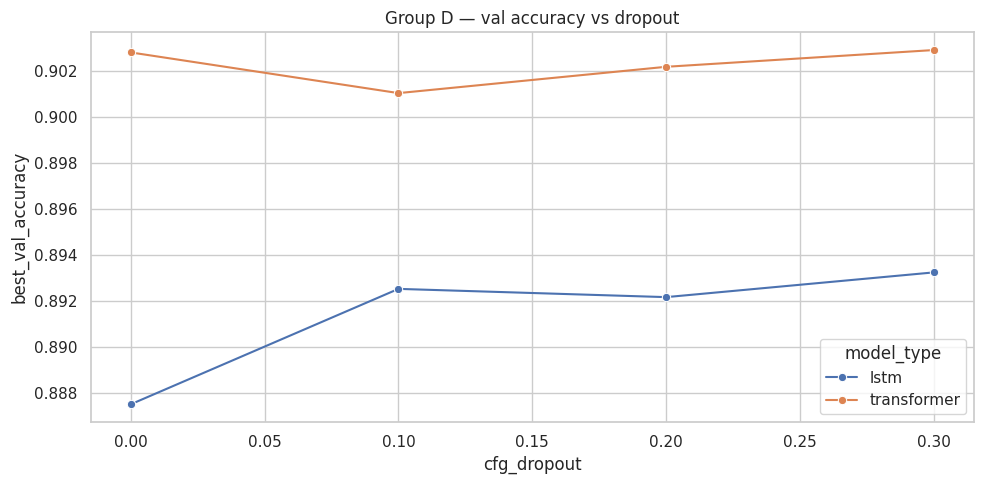

### Group D — batch size sweep

,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,group,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
0,D_lstm_batch_16,lstm,0.891082,0.383017,37.573199,2052883,12,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_batch_16.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.889316,0.887187,0.889316,0.886824,32,gpu,D_lstm_batch_16,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,16,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2000,30,42,42,6460,19,128.0,NaN,NaN
1,D_lstm_batch_32,lstm,0.887493,0.383989,24.455274,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_batch_32.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.890738,0.889578,0.890738,0.887984,32,gpu,D_lstm_batch_32,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2000,30,42,42,6460,19,128.0,NaN,NaN
2,D_lstm_batch_64,lstm,0.886058,0.385026,16.879781,2052883,20,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_batch_64.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.891165,0.889428,0.891165,0.888729,32,gpu,D_lstm_batch_64,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,64,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2000,30,42,42,6460,19,128.0,NaN,NaN
3,D_lstm_batch_128,lstm,0.877983,0.432619,9.990076,2052883,20,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_batch_128.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.879784,0.874497,0.879784,0.875968,32,gpu,D_lstm_batch_128,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,128,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2000,30,42,42,6460,19,128.0,NaN,NaN
4,D_transformer_batch_32,transformer,0.903646,0.326257,19.282080,6401299,7,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_transformer_batch_32.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.827998,0.828966,0.827998,0.827033,32,gpu,D_transformer_batch_32,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,transformer,2000,30,42,42,256,8.0,512.0,2.0,0.1,0.0010,20,32,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2

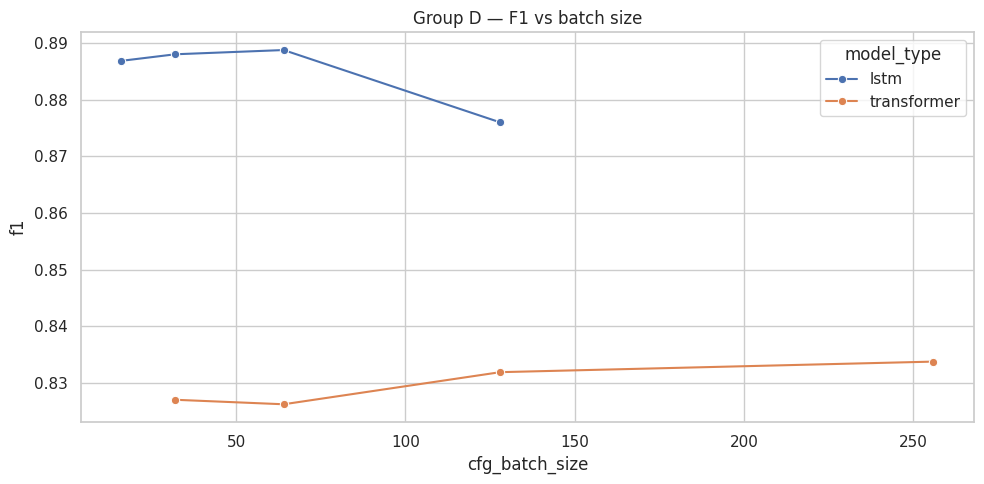

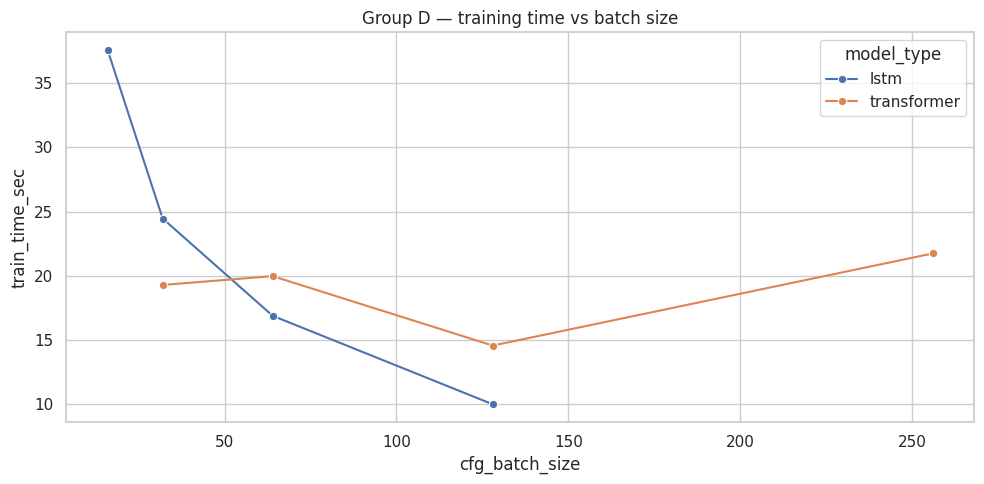

In [18]:
group_d = get_group(df, "D_optimization_sensitivity")
display(group_d.sort_values(["model_type", "name"]).reset_index(drop=True))

# Learning rate sweep
lr_runs = group_d[group_d["name"].str.contains("lr_", na=False)].copy()
if not lr_runs.empty:
    display(Markdown("### Group D — learning rate sweep"))
    display(lr_runs.sort_values(["model_type", "cfg_lr"]).reset_index(drop=True))
    plot_line(lr_runs, x="cfg_lr", y="f1", title="Group D — F1 vs learning rate")
    plot_line(lr_runs, x="cfg_lr", y="best_val_accuracy", title="Group D — val accuracy vs learning rate")

# Dropout sweep (primarily transformer)
dropout_runs = group_d[group_d["name"].str.contains("dropout_", na=False)].copy()
if not dropout_runs.empty:
    display(Markdown("### Group D — dropout sweep"))
    display(dropout_runs.sort_values(["model_type", "cfg_dropout"]).reset_index(drop=True))
    plot_line(dropout_runs, x="cfg_dropout", y="f1", title="Group D — F1 vs dropout")
    plot_line(dropout_runs, x="cfg_dropout", y="best_val_accuracy", title="Group D — val accuracy vs dropout")

# Batch-size sweep
batch_runs = group_d[group_d["name"].str.contains("batch_", na=False)].copy()
if not batch_runs.empty:
    display(Markdown("### Group D — batch size sweep"))
    display(batch_runs.sort_values(["model_type", "cfg_batch_size"]).reset_index(drop=True))
    plot_line(batch_runs, x="cfg_batch_size", y="f1", title="Group D — F1 vs batch size")
    plot_line(batch_runs, x="cfg_batch_size", y="train_time_sec", title="Group D — training time vs batch size")


# Group E — Robustness across split seeds and run seeds

**Hypothesis**  
Some apparent wins may be unstable and depend on lucky data splits or training randomness.

**Controlled factors**
- same sentence count
- same max length
- same architecture per family

**Varied factors**
- `split_seed`
- `run_seed`

**What to look for**
- Compare **mean** and **std** of `f1` per model family
- Does Transformer still win on average?
- Is one family more stable (lower variance)?
- Are changes caused more by data split or by training seed?
- A stable small win is usually more trustworthy than a big but inconsistent win


,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,group,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
0,E_lstm_stronger_split7_run7,lstm,0.887910,0.366097,22.995309,2052883,15,/home/dan-gavriluta/Coding/ml-project/resources/models/group_E_robustness/E_lstm_stronger_split7_run7.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness,0.892398,0.890769,0.892398,0.889437,32,gpu,E_lstm_stronger_split7_run7,E_robustness,H10_results_not_stable_across_seeds,lstm,2000,30,7,7,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,E_robustness,H10_results_not_stable_across_seeds,2000,30,7,7,6460,19,128.0,NaN,NaN
1,E_lstm_stronger_split7_run42,lstm,0.889672,0.380963,25.877843,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_E_robustness/E_lstm_stronger_split7_run42.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness,0.891683,0.888274,0.891683,0.889203,32,gpu,E_lstm_stronger_split7_run42,E_robustness,H10_results_not_stable_across_seeds,lstm,2000,30,7,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,E_robustness,H10_results_not_stable_across_seeds,2000,30,7,42,6460,19,128.0,NaN,NaN
2,E_lstm_stronger_split7_run123,lstm,0.889848,0.372578,25.892051,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_E_robustness/E_lstm_stronger_split7_run123.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness,0.897542,0.898191,0.897542,0.894989,32,gpu,E_lstm_stronger_split7_run123,E_robustness,H10_results_not_stable_across_seeds,lstm,2000,30,7,123,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,E_robustness,H10_results_not_stable_across_seeds,2000,30,7,123,6460,19,128.0,NaN,NaN
3,E_lstm_stronger_split42_run7,lstm,0.890544,0.371650,25.383158,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_E_robustness/E_lstm_stronger_split42_run7.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness,0.893015,0.891886,0.893015,0.890560,32,gpu,E_lstm_stronger_split42_run7,E_robustness,H10_results_not_stable_across_seeds,lstm,2000,30,42,7,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,E_robustness,H10_results_not_stable_across_seeds,2000,30,42,7,6460,19,128.0,NaN,NaN
4,E_lstm_stronger_split42_run42,lstm,0.887493,0.383989,25.679073,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_E_robustness/E_lstm_stronger_split42_run42.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness,0.890738,0.889578,0.890738,0.887984,32,gpu,E_lstm_stronger_split42_run42,E_robustness,H10_results_not_stable_across_seeds,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,E_robustness,H10_results_not_stable_across_seeds,2000,30,42,42,6460,19,128.0,NaN,NaN
5,E_lstm_stronger_split42_run123,lstm,0.890723,0.372194,25.565822,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_E_robustness/E_lstm_stronger_split42_run123.keras,False,

### Group E — summary by model type

,model_type,count,mean,std,min,max
0,lstm,9,0.889068,0.003383,0.882651,0.894989
1,transformer,9,0.827298,0.005318,0.817797,0.833114


### Group E — summary by model type and split seed

,model_type,split_seed,count,mean,std,min,max
0,lstm,7,3,0.891209,0.003275,0.889203,0.894989
1,lstm,42,3,0.889481,0.001338,0.887984,0.890560
2,lstm,123,3,0.886513,0.004042,0.882651,0.890715
3,transformer,7,3,0.831168,0.001842,0.829452,0.833114
4,transformer,123,3,0.825924,0.004028,0.823501,0.830573
5,transformer,42,3,0.824801,0.007672,0.817797,0.833001


### Group E — summary by model type and run seed

,model_type,run_seed,count,mean,std,min,max
0,lstm,123,3,0.891868,0.002733,0.889899,0.894989
1,lstm,7,3,0.888723,0.002280,0.886172,0.890560
2,lstm,42,3,0.886612,0.003484,0.882651,0.889203
3,transformer,42,3,0.828717,0.004695,0.823698,0.833001
4,transformer,123,3,0.827162,0.008209,0.817797,0.833114
5,transformer,7,3,0.826015,0.004264,0.823501,0.830938


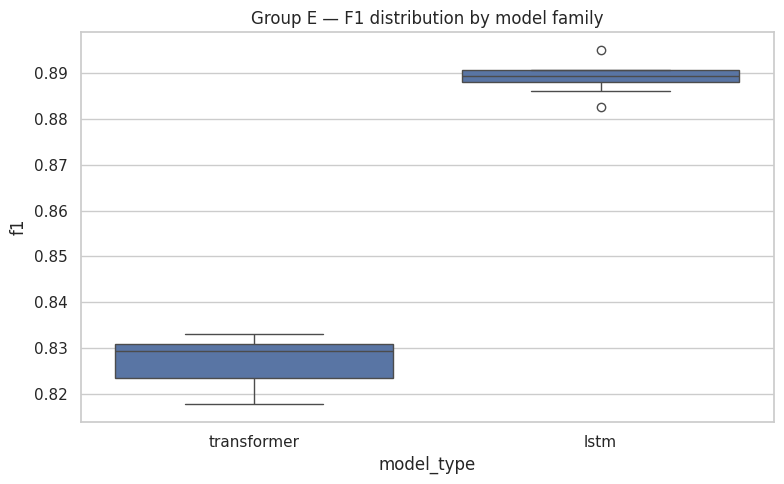

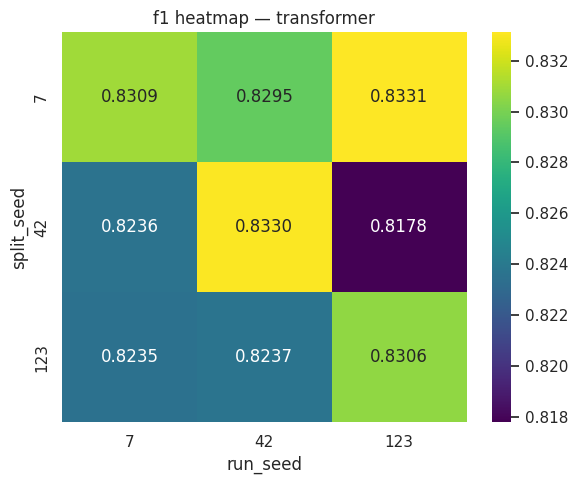

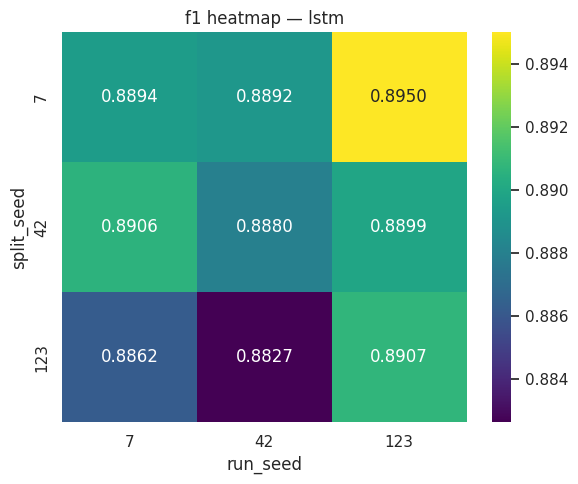

In [19]:
group_e = get_group(df, "E_robustness")
display(group_e.sort_values(["model_type", "split_seed", "run_seed"]).reset_index(drop=True))

display(Markdown("### Group E — summary by model type"))
display(grouped_summary(group_e, by="model_type", metric="f1"))

display(Markdown("### Group E — summary by model type and split seed"))
display(grouped_summary(group_e, by=["model_type", "split_seed"], metric="f1"))

display(Markdown("### Group E — summary by model type and run seed"))
display(grouped_summary(group_e, by=["model_type", "run_seed"], metric="f1"))

plt.figure(figsize=(8, 5))
sns.boxplot(data=group_e, x="model_type", y="f1")
plt.title("Group E — F1 distribution by model family")
plt.tight_layout()
plt.show()

heatmap_split_seed_vs_run_seed(group_e, metric="f1", model_type="transformer")
heatmap_split_seed_vs_run_seed(group_e, metric="f1", model_type="lstm")


# Group F — LR warmup sensitivity

**Hypothesis**
Linear LR warmup should stabilise Transformer training and improve final accuracy; LSTM is largely unaffected because it converges more smoothly from step one.

**Controlled factors**
- same architecture (medium transformer / stronger LSTM)
- same sentence count, max length, split seed, run seed
- only `lr_warmup_steps` varies (0 = no warmup)

**What to look for**
- Does F1 increase monotonically with warmup steps, or is there a sweet spot?
- Do the early validation curves look smoother with warmup?
- Is the transformer gain from warmup larger than the LSTM gain (if any)?
- At too many warmup steps, does the model run out of "warm" budget before converging?

In [ ]:
group_f = get_group(df, "F_lr_warmup")

if group_f.empty:
    print("No Group F results yet. Run experiments first.")
else:
    if "cfg_lr_warmup_steps" in group_f.columns:
        group_f["cfg_lr_warmup_steps"] = group_f["cfg_lr_warmup_steps"].fillna(0).astype(int)

    display(group_f.sort_values(["model_type", "cfg_lr_warmup_steps"]).reset_index(drop=True))

    t_warmup = group_f[group_f["model_type"] == "transformer"].copy()
    if not t_warmup.empty:
        display(Markdown("### Group F — transformer warmup sweep"))
        display(t_warmup.sort_values("cfg_lr_warmup_steps")[leaderboard_cols].reset_index(drop=True))
        plot_line(t_warmup.sort_values("cfg_lr_warmup_steps"), x="cfg_lr_warmup_steps", y="f1",
                  title="Group F — transformer F1 vs warmup steps")
        plot_line(t_warmup.sort_values("cfg_lr_warmup_steps"), x="cfg_lr_warmup_steps", y="best_val_accuracy",
                  title="Group F — transformer val accuracy vs warmup steps")

    l_warmup = group_f[group_f["model_type"] == "lstm"].copy()
    if not l_warmup.empty:
        display(Markdown("### Group F — LSTM warmup comparison"))
        display(l_warmup.sort_values("cfg_lr_warmup_steps")[leaderboard_cols].reset_index(drop=True))

    display(Markdown("### Group F — summary by model type and warmup"))
    display(grouped_summary(group_f, by=["model_type", "cfg_lr_warmup_steps"], metric="f1"))

    plot_bar(group_f, metric=SELECTION_METRIC, title="Group F — LR warmup: main metric")
    plot_histories(runs, "F_lr_warmup", "val_accuracy")
    plot_histories(runs, "F_lr_warmup", "val_loss")

# Group G — Architecture Depth

**Hypothesis**
Adding more layers (depth) helps both families, but the effect is stronger for transformers.

**Controlled factors**
- same sentence count, max length, seeds
- same embed_dim / ff_dim / lstm_units per family

**Varied factors**
- `lstm_layers`: 1, 2  
- `num_layers` (transformer): 1, 2, 3, 4

**What to look for**
- Does stacking a second BiLSTM layer improve LSTM performance or hurt it (overfitting / vanishing gradients)?
- Does the transformer improve monotonically with depth, or plateau/degrade at 3–4 layers?
- Which family shows diminishing returns earlier?
- How much extra training time does each additional layer cost per family?
- Do deeper transformers need more dropout to stay well-behaved?

### Group G — leaderboard

,name,group,model_type,token_accuracy,f1,precision,recall,best_val_accuracy,best_val_loss,train_time_sec,epochs_ran
0,G_lstm_1layer,G_architecture_depth,lstm,0.890738,0.887984,0.889578,0.890738,0.887493,0.383989,30.021640,16
1,G_lstm_2layers,G_architecture_depth,lstm,0.872813,0.869096,0.870230,0.872813,0.874574,0.467991,43.627816,13
2,G_transformer_2layers,G_architecture_depth,transformer,0.833974,0.831736,0.835624,0.833974,0.903854,0.322733,15.021177,10
3,G_transformer_4layers,G_architecture_depth,transformer,0.831840,0.830659,0.832816,0.831840,0.903646,0.382655,24.326643,13
4,G_transformer_1layer,G_architecture_depth,transformer,0.827714,0.827228,0.831093,0.827714,0.902396,0.318546,18.836372,10
5,G_transformer_3layers,G_architecture_depth,transformer,0.827998,0.826881,0.829115,0.827998,0.902188,0.354832,19.427913,12


### Group G — config

,name,model_type,num_params,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_lstm_units,cfg_lstm_layers,cfg_dropout,cfg_lr,cfg_lr_warmup_steps,cfg_batch_size
0,G_lstm_1layer,lstm,2052883,256,NaN,NaN,NaN,128.0,1.0,NaN,0.0005,NaN,32
1,G_lstm_2layers,lstm,2447123,256,NaN,NaN,NaN,128.0,2.0,NaN,0.0005,NaN,32
2,G_transformer_1layer,transformer,4033811,256,8.0,512.0,1.0,NaN,NaN,0.10,0.0010,NaN,128
3,G_transformer_2layers,transformer,6401299,256,8.0,512.0,2.0,NaN,NaN,0.10,0.0010,NaN,128
4,G_transformer_3layers,transformer,8768787,256,8.0,512.0,3.0,NaN,NaN,0.15,0.0010,NaN,128
5,G_transformer_4layers,transformer,11136275,256,8.0,512.0,4.0,NaN,NaN,0.20,0.0010,NaN,128


### Transformer: F1 vs num_layers

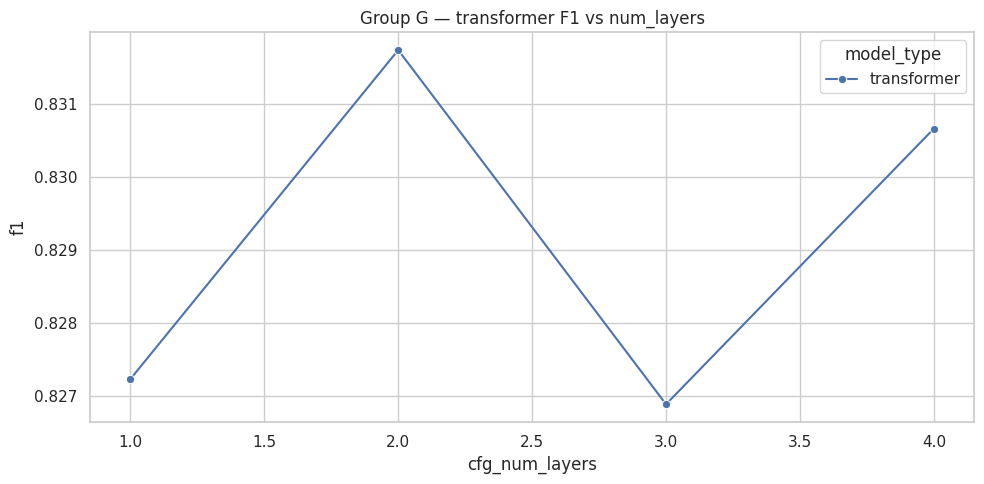

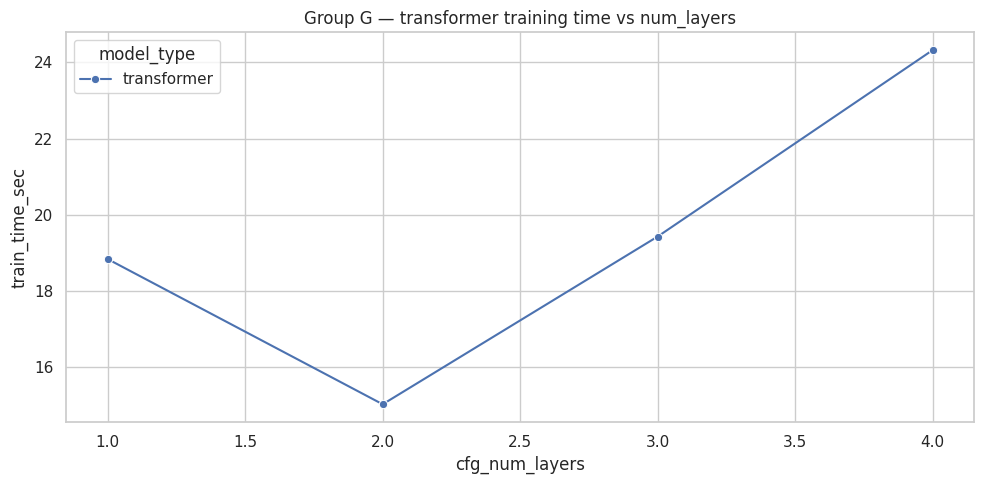

### LSTM: F1 vs lstm_layers

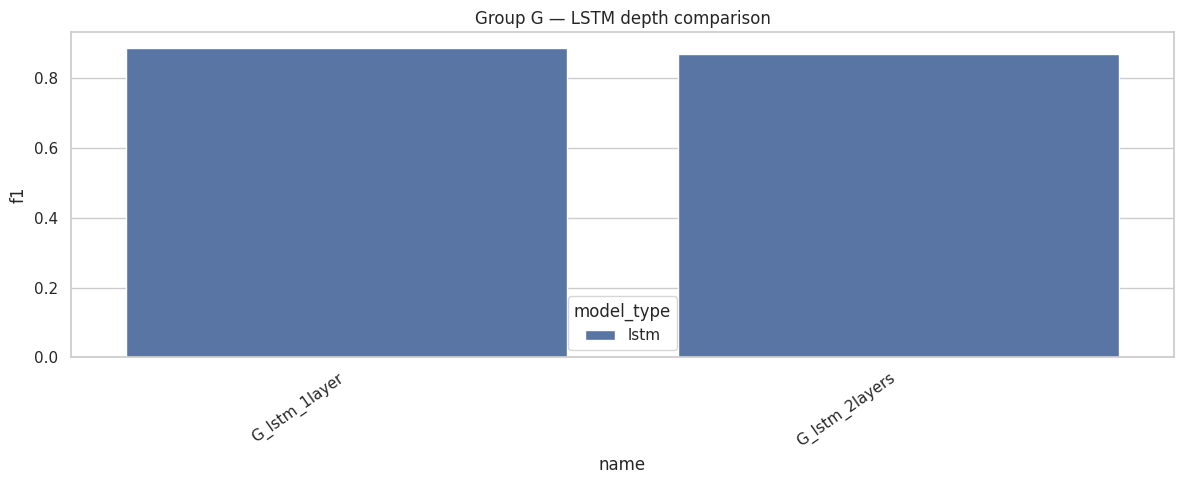

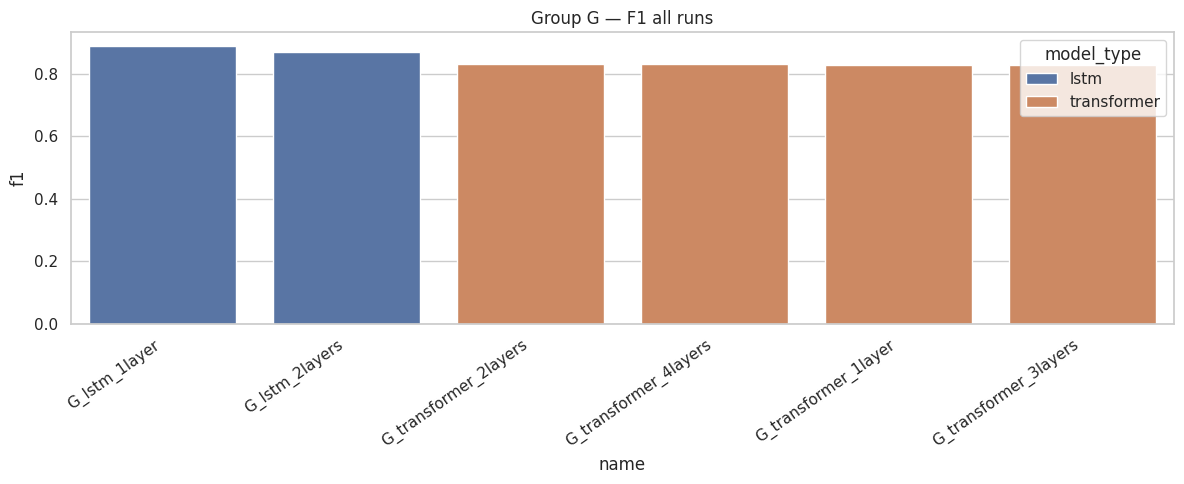

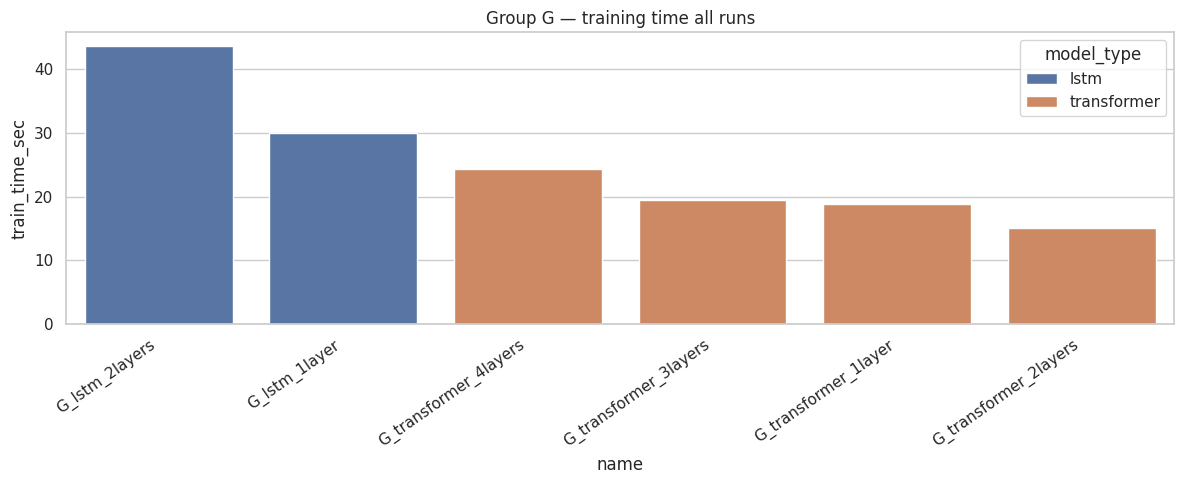

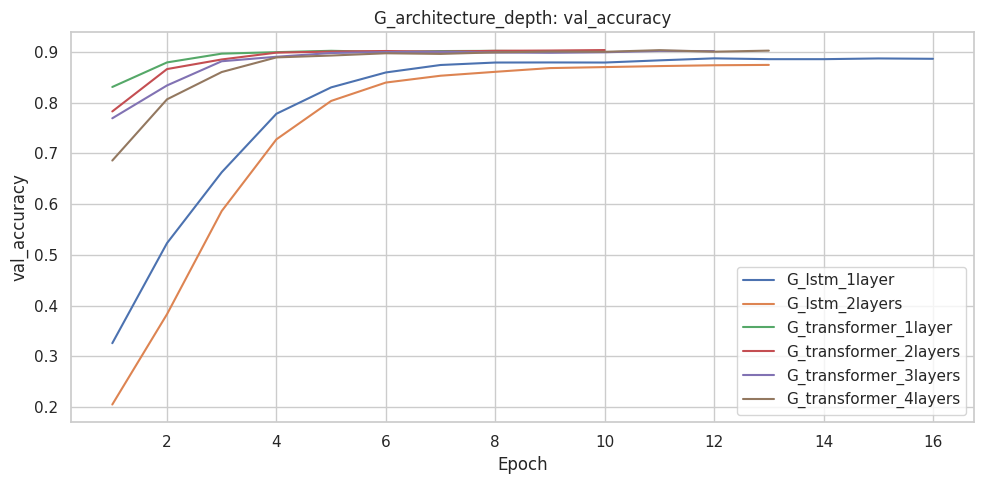

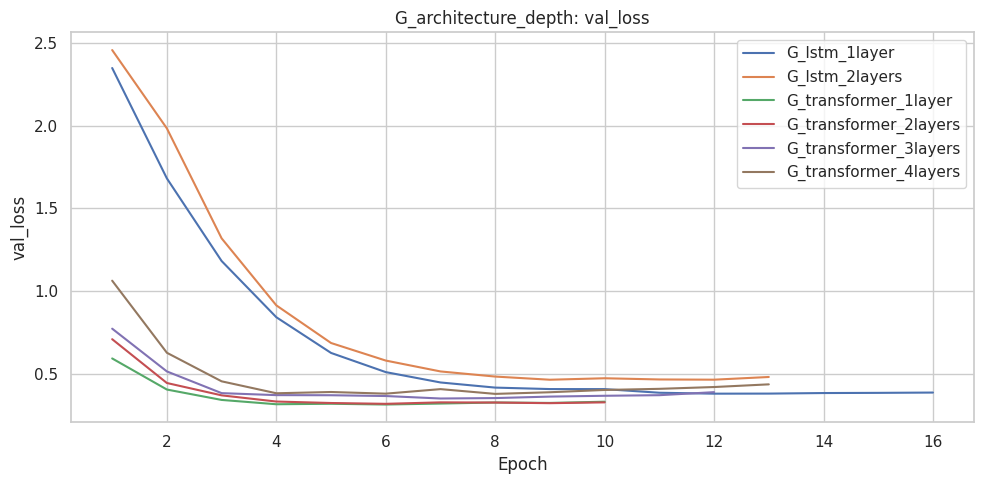

### Group G — summary by model type and depth

,model_type,cfg_num_layers,count,mean,std,min,max
0,lstm,NaN,2,0.878540,0.013355,0.869096,0.887984
1,transformer,2.0,1,0.831736,NaN,0.831736,0.831736
2,transformer,4.0,1,0.830659,NaN,0.830659,0.830659
3,transformer,1.0,1,0.827228,NaN,0.827228,0.827228
4,transformer,3.0,1,0.826881,NaN,0.826881,0.826881


In [21]:
group_g = get_group(df, "G_architecture_depth")

if group_g.empty:
    print("No Group G results yet.")
else:
    display(Markdown("### Group G — leaderboard"))
    display(
        group_g[leaderboard_cols]
        .sort_values(SELECTION_METRIC, ascending=False)
        .reset_index(drop=True)
    )

    display(Markdown("### Group G — config"))
    display(
        group_g[[c for c in config_cols if c in group_g.columns]]
        .sort_values(["model_type", "name"])
        .reset_index(drop=True)
    )

    # Unify depth into one column
    group_g = group_g.copy()
    group_g["depth"] = group_g["cfg_num_layers"].fillna(group_g.get("cfg_lstm_layers", float("nan")))

    # Transformer depth sweep
    g_transformer = group_g[group_g["model_type"] == "transformer"].sort_values("cfg_num_layers")
    if not g_transformer.empty:
        display(Markdown("### Transformer: F1 vs num_layers"))
        plot_line(
            g_transformer,
            x="cfg_num_layers",
            y="f1",
            hue="model_type",
            title="Group G — transformer F1 vs num_layers",
        )
        plot_line(
            g_transformer,
            x="cfg_num_layers",
            y="train_time_sec",
            hue="model_type",
            title="Group G — transformer training time vs num_layers",
        )

    # LSTM depth sweep
    g_lstm = group_g[group_g["model_type"] == "lstm"].copy()
    if "cfg_lstm_layers" in g_lstm.columns:
        g_lstm = g_lstm.sort_values("cfg_lstm_layers")
    if not g_lstm.empty:
        display(Markdown("### LSTM: F1 vs lstm_layers"))
        plot_bar(g_lstm, metric=SELECTION_METRIC, title="Group G — LSTM depth comparison")

    # Combined bar
    plot_bar(group_g, metric=SELECTION_METRIC, title="Group G — F1 all runs")
    plot_bar(group_g, metric="train_time_sec", title="Group G — training time all runs")

    # Training curves
    plot_histories(runs, "G_architecture_depth", "val_accuracy")
    plot_histories(runs, "G_architecture_depth", "val_loss")

    display(Markdown("### Group G — summary by model type and depth"))
    display(grouped_summary(group_g, by=["model_type", "cfg_num_layers"], metric="f1"))

# Final interpretation checklist

When writing conclusions, try to answer these directly:

## Group A
- On the default setup, does Transformer beat LSTM? Using F1, nope.
- By how much, and at what time cost?

## Group B
- Is LSTM more competitive on small data?
- Does Transformer scale better with more data?

## Group C
- Does Transformer benefit more from longer context?

## Group D
- Which family is more sensitive to LR, dropout, and batch size?
- Which family is easier to tune?

## Group E
- Are your conclusions stable across seeds?
- Is the winner robust, or fragile?

## Group F
- Does LR warmup improve the transformer? By how much?
- Is there a sweet spot for warmup length?
- Is the LSTM indifferent to warmup, as expected?

## Group G
- Does stacking a second BiLSTM layer help or hurt?
- Does the transformer improve with depth up to 3–4 layers, or plateau?
- How does training cost scale with depth per family?

## Final decision
- Best raw model:
- Best practical model:
- Best robust model:
- Best model for small data:
- Best model for long context:
- Best model after warmup tuning:
- Best model at optimal depth:

# Best models: overall, per group, and practical winner

This section helps answer three different questions:

1. **Best raw model** — highest chosen selection metric
2. **Best per group** — winner inside each hypothesis group
3. **Best practical model** — strong quality with lower training cost

**What to look for**
- Does the same config keep winning across multiple views?
- Is the “best” model only marginally better but much slower?
- Does a consistent winner emerge across groups A–E?


In [23]:
if not df.empty:
    display(Markdown("### Best overall by selection metric"))
    display(df.sort_values(SELECTION_METRIC, ascending=False).head(10).reset_index(drop=True))

    display(Markdown("### Best per group"))
    best_per_group = (
        df.sort_values(SELECTION_METRIC, ascending=False)
          .groupby("group", as_index=False)
          .first()
          .sort_values(SELECTION_METRIC, ascending=False)
    )
    display(best_per_group)

    display(Markdown("### Best per group and model type"))
    best_per_group_type = (
        df.sort_values(SELECTION_METRIC, ascending=False)
          .groupby(["group", "model_type"], as_index=False)
          .first()
          .sort_values(["group", SELECTION_METRIC], ascending=[True, False])
    )
    display(best_per_group_type)

    display(Markdown("### Practical winner (quality minus small time penalty)"))
    practical_df = practical_score(df, metric=SELECTION_METRIC, time_penalty=0.001)
    display(practical_df.sort_values("practical_score", ascending=False).head(15).reset_index(drop=True))


### Best overall by selection metric

,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,group,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
0,B_lstm_stronger_smax,lstm,0.926444,0.259970,106.397920,4764435,9,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_lstm_stronger_smax.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.926844,0.926690,0.926844,0.925927,32,gpu,B_lstm_stronger_smax,B_data_regime,H4_transformer_scales_better_with_more_data,lstm,max,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,17052,19,B_data_regime,H4_transformer_scales_better_with_more_data,12543,30,42,42,17052,19,128.0,NaN,NaN
1,B_lstm_stronger_s5000,lstm,0.919581,0.294662,40.801338,2843667,11,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_lstm_stronger_s5000.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.907544,0.909223,0.907544,0.907573,32,gpu,B_lstm_stronger_s5000,B_data_regime,H4_transformer_scales_better_with_more_data,lstm,5000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,9549,19,B_data_regime,H4_transformer_scales_better_with_more_data,5000,30,42,42,9549,19,128.0,NaN,NaN
2,B_transformer_medium_smax,transformer,0.906029,0.367445,42.921002,9112851,7,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_transformer_medium_smax.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.897979,0.900439,0.897979,0.896975,32,gpu,B_transformer_medium_smax,B_data_regime,H4_transformer_scales_better_with_more_data,transformer,max,30,42,42,256,8.0,512.0,2.0,0.1,0.0010,20,128,True,4,0.2,17052,19,B_data_regime,H4_transformer_scales_better_with_more_data,12543,30,42,42,17052,19,NaN,NaN,NaN
3,C_lstm_stronger_len100,lstm,0.894381,0.373722,74.365063,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_C_context_length_regime/C_lstm_stronger_len100.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime,0.897549,0.896324,0.897549,0.895106,32,gpu,C_lstm_stronger_len100,C_context_length_regime,H3_transformer_gains_more_from_longer_context,lstm,2000,100,42,42,256,NaN,NaN,NaN,NaN,0.0005,24,32,True,5,0.2,6460,19,C_context_length_regime,H3_transformer_gains_more_from_longer_context,2000,100,42,42,6460,19,128.0,NaN,NaN
4,C_lstm_stronger_len50,lstm,0.893349,0.371070,38.662162,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_C_context_length_regime/C_lstm_stronger_len50.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime,0.897557,0.896262,0.897557,0.895036,32,gpu,C_lstm_stronger_len50,C_context_length_regime,H3_transformer_gains_more_from_longer_context,lstm,2000,50,42,42,256,NaN,NaN,NaN,NaN,0.0005,22,32,True,4,0.2,6460,19,C_context_length_regime,H3_transformer_gains_more_from_longer_context,2000,50,42,42,6460,19,128.0,NaN,NaN
5,E_lstm_stronger_split7_run123,lstm,0.889848,0.3

### Best per group

,group,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
1,B_data_regime,B_lstm_stronger_smax,lstm,0.926444,0.259970,106.397920,4764435,9,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_lstm_stronger_smax.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.926844,0.926690,0.926844,0.925927,32,gpu,B_lstm_stronger_smax,B_data_regime,H4_transformer_scales_better_with_more_data,lstm,max,30,42,42,256,8.0,512.0,2.0,0.1,0.0005,20,32,True,4,0.2,17052,19,H4_transformer_scales_better_with_more_data,12543,30,42,42,17052,19,128.0,NaN,NaN
2,C_context_length_regime,C_lstm_stronger_len100,lstm,0.894381,0.373722,74.365063,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_C_context_length_regime/C_lstm_stronger_len100.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime,0.897549,0.896324,0.897549,0.895106,32,gpu,C_lstm_stronger_len100,C_context_length_regime,H3_transformer_gains_more_from_longer_context,lstm,2000,100,42,42,256,8.0,512.0,2.0,0.1,0.0005,24,32,True,5,0.2,6460,19,H3_transformer_gains_more_from_longer_context,2000,100,42,42,6460,19,128.0,NaN,NaN
4,E_robustness,E_lstm_stronger_split7_run123,lstm,0.889848,0.372578,25.892051,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_E_robustness/E_lstm_stronger_split7_run123.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness,0.897542,0.898191,0.897542,0.894989,32,gpu,E_lstm_stronger_split7_run123,E_robustness,H10_results_not_stable_across_seeds,lstm,2000,30,7,123,256,8.0,512.0,2.0,0.1,0.0005,20,32,True,4,0.2,6460,19,H10_results_not_stable_across_seeds,2000,30,7,123,6460,19,128.0,NaN,NaN
3,D_optimization_sensitivity,D_lstm_dropout_02,lstm,0.892159,0.374044,26.133188,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_dropout_02.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.894437,0.893797,0.894437,0.892042,32,gpu,D_lstm_dropout_02,D_optimization_sensitivity,H8_transformer_more_sensitive_to_dropout,lstm,2000,30,42,42,256,8.0,512.0,2.0,0.2,0.0005,22,32,True,4,0.2,6460,19,H8_transformer_more_sensitive_to_dropout,2000,30,42,42,6460,19,128.0,NaN,NaN
0,A_baseline_family_comparison,A_lstm_stronger,lstm,0.887493,0.383989,25.682021,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_A_baseline_family_comparison/A_lstm_stronger.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_A_baseline_family_comparison/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_A_baseline_family_comparison,0.890738,0.889578,0.890738,0.887984,32,gpu,A_lstm_stronger,A_baseline_family_comparison,H1_transformer_beats_lstm_default,lstm,2000,30,42,42,256,4.0,128.0,1.0,0.1,0.0005,20,32,True,4,0.2,6460,19,H1_transformer_beats_lstm_default,2000,30,42,42,6460,19,128.0,NaN,NaN
5,F_lr_warmup,F_lstm_no_warmup,lst

### Best per group and model type

,group,model_type,name,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers
0,A_baseline_family_comparison,lstm,A_lstm_stronger,0.887493,0.383989,25.682021,2052883,16,/home/dan-gavriluta/Coding/ml-project/resources/models/group_A_baseline_family_comparison/A_lstm_stronger.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_A_baseline_family_comparison/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_A_baseline_family_comparison,0.890738,0.889578,0.890738,0.887984,32,gpu,A_lstm_stronger,A_baseline_family_comparison,H1_transformer_beats_lstm_default,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,H1_transformer_beats_lstm_default,2000,30,42,42,6460,19,128.0,NaN,NaN
1,A_baseline_family_comparison,transformer,A_transformer_small,0.834739,0.552305,13.456119,1130515,7,/home/dan-gavriluta/Coding/ml-project/resources/models/group_A_baseline_family_comparison/A_transformer_small.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_A_baseline_family_comparison/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_A_baseline_family_comparison,0.832266,0.834316,0.832266,0.830228,32,gpu,A_transformer_small,A_baseline_family_comparison,H1_transformer_beats_lstm_default,transformer,2000,30,42,42,128,4.0,128.0,1.0,0.1,0.0010,12,64,True,3,0.2,6460,19,H1_transformer_beats_lstm_default,2000,30,42,42,6460,19,NaN,NaN,NaN
2,B_data_regime,lstm,B_lstm_stronger_smax,0.926444,0.259970,106.397920,4764435,9,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_lstm_stronger_smax.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.926844,0.926690,0.926844,0.925927,32,gpu,B_lstm_stronger_smax,B_data_regime,H4_transformer_scales_better_with_more_data,lstm,max,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,17052,19,H4_transformer_scales_better_with_more_data,12543,30,42,42,17052,19,128.0,NaN,NaN
3,B_data_regime,transformer,B_transformer_medium_smax,0.906029,0.367445,42.921002,9112851,7,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_transformer_medium_smax.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.897979,0.900439,0.897979,0.896975,32,gpu,B_transformer_medium_smax,B_data_regime,H4_transformer_scales_better_with_more_data,transformer,max,30,42,42,256,8.0,512.0,2.0,0.1,0.0010,20,128,True,4,0.2,17052,19,H4_transformer_scales_better_with_more_data,12543,30,42,42,17052,19,NaN,NaN,NaN
4,C_context_length_regime,lstm,C_lstm_stronger_len100,0.894381,0.373722,74.365063,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_C_context_length_regime/C_lstm_stronger_len100.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_C_context_length_regime,0.897549,0.896324,0.897549,0.895106,32,gpu,C_lstm_stronger_len100,C_context_length_regime,H3_transformer_gains_more_from_longer_context,lstm,2000,100,42,42,256,NaN,NaN,NaN,NaN,0.0005,24,32,True,5,0.2,6460,19,H3_transformer_gains_more_from_longer_context,2000,100,42,42,6460,19,128.0,NaN,NaN
5,C_

### Practical winner (quality minus small time penalty)

,name,model_type,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran,model_path,model_saved,_results_file,_results_folder,token_accuracy,precision,recall,f1,predict_batch_size_used,predict_device,cfg_name,cfg_group,cfg_hypothesis,cfg_model_type,cfg_sentences,cfg_maxlen,cfg_split_seed,cfg_seed,cfg_embed_dim,cfg_num_heads,cfg_ff_dim,cfg_num_layers,cfg_dropout,cfg_lr,cfg_epochs,cfg_batch_size,cfg_early_stopping,cfg_patience,cfg_validation_split,cfg_vocab_size,cfg_num_tags,group,hypothesis,sentences,maxlen,split_seed,run_seed,vocab_size,num_tags,cfg_lstm_units,cfg_lr_warmup_steps,cfg_lstm_layers,practical_score
0,D_lstm_batch_64,lstm,0.886058,0.385026,16.879781,2052883,20,/home/dan-gavriluta/Coding/ml-project/resources/models/group_D_optimization_sensitivity/D_lstm_batch_64.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_D_optimization_sensitivity,0.891165,0.889428,0.891165,0.888729,32,gpu,D_lstm_batch_64,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,lstm,2000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,64,True,4,0.2,6460,19,D_optimization_sensitivity,H9_batch_size_affects_transformer_more,2000,30,42,42,6460,19,128.0,NaN,NaN,0.871850
1,E_lstm_stronger_split7_run123,lstm,0.889848,0.372578,25.892051,2052883,17,/home/dan-gavriluta/Coding/ml-project/resources/models/group_E_robustness/E_lstm_stronger_split7_run123.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness,0.897542,0.898191,0.897542,0.894989,32,gpu,E_lstm_stronger_split7_run123,E_robustness,H10_results_not_stable_across_seeds,lstm,2000,30,7,123,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,E_robustness,H10_results_not_stable_across_seeds,2000,30,7,123,6460,19,128.0,NaN,NaN,0.869097
2,B_lstm_stronger_s5000,lstm,0.919581,0.294662,40.801338,2843667,11,/home/dan-gavriluta/Coding/ml-project/resources/models/group_B_data_regime/B_lstm_stronger_s5000.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_B_data_regime,0.907544,0.909223,0.907544,0.907573,32,gpu,B_lstm_stronger_s5000,B_data_regime,H4_transformer_scales_better_with_more_data,lstm,5000,30,42,42,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,9549,19,B_data_regime,H4_transformer_scales_better_with_more_data,5000,30,42,42,9549,19,128.0,NaN,NaN,0.866772
3,A_lstm_baseline,lstm,0.888032,0.384210,21.248130,928147,13,/home/dan-gavriluta/Coding/ml-project/resources/models/group_A_baseline_family_comparison/A_lstm_baseline.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_A_baseline_family_comparison/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_A_baseline_family_comparison,0.890596,0.891803,0.890596,0.887874,32,gpu,A_lstm_baseline,A_baseline_family_comparison,H1_transformer_beats_lstm_default,lstm,2000,30,42,42,128,NaN,NaN,NaN,NaN,0.0010,15,32,True,3,0.2,6460,19,A_baseline_family_comparison,H1_transformer_beats_lstm_default,2000,30,42,42,6460,19,64.0,NaN,NaN,0.866626
4,E_lstm_stronger_split7_run7,lstm,0.887910,0.366097,22.995309,2052883,15,/home/dan-gavriluta/Coding/ml-project/resources/models/group_E_robustness/E_lstm_stronger_split7_run7.keras,False,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness/training_results.json,/home/dan-gavriluta/Coding/ml-project/resources/results/group_E_robustness,0.892398,0.890769,0.892398,0.889437,32,gpu,E_lstm_stronger_split7_run7,E_robustness,H10_results_not_stable_across_seeds,lstm,2000,30,7,7,256,NaN,NaN,NaN,NaN,0.0005,20,32,True,4,0.2,6460,19,E_robustness,H10_results_not_stable_across_seeds,2000,30,7,7,6460,19,128.0,NaN,NaN,0.866442
5,E_lstm_stronger_split123_run123,lstm,0.888793,0.373577,24.